In [ ]:
'''
Approach:
==========
1 . load the data and load all the libraries.
2 . Data Audit(Shape of the data , Missing values , Inconsistencies etc)
3 . Data Preparation(Missing values Inconsistency, remove redundancy)
4 . Data Visualization(Boxplots and frquency plots)
5 . Data Analysis 
    1. Uni-Variate (Measures of Central Tendency , Measures of Dispersion)
    2. Bi-Variate (Covariance and Correlation/chi-square test)
    3. Multi-Variate (Linear Regression)

'''

Installing Libraries

In [1]:
import pandas as pd 
import numpy as  np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import  mean_squared_error
from sklearn.metrics import r2_score

Import data

In [2]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

In [3]:
train_data.shape

(8523, 12)

In [4]:
test_data.shape

(5681, 11)

Audit the data


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


Summary Statistics

In [7]:
train_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [8]:
train_data.skew()

C:\Users\User\AppData\Local\Temp\ipykernel_7348\2564673981.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  train_data.skew()


Item_Weight                  0.082426
Item_Visibility              1.167091
Item_MRP                     0.127202
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
dtype: float64

<AxesSubplot:>

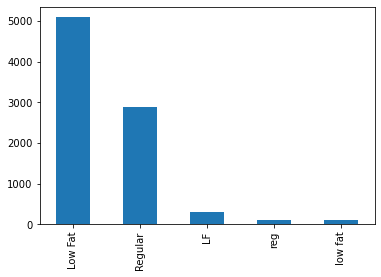

In [9]:
train_data['Item_Fat_Content'].value_counts().plot.bar()

In [10]:
train_data['Item_Fat_Content'].value_counts()

Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: Item_Fat_Content, dtype: int64

In [11]:
train_data['Item_Type'].value_counts()

Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: Item_Type, dtype: int64

<AxesSubplot:>

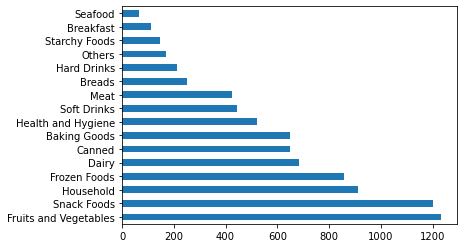

In [12]:
train_data['Item_Type'].value_counts().plot.barh()

In [13]:
train_data['Outlet_Type'].value_counts()

Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: Outlet_Type, dtype: int64

<AxesSubplot:>

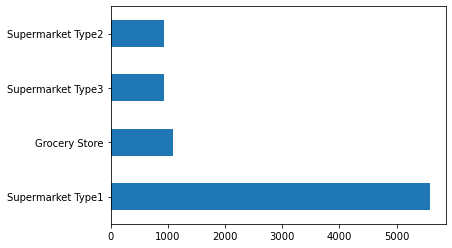

In [14]:
train_data['Outlet_Type'].value_counts().plot.barh()

Data Preparation

In [15]:
def data_prep(train_data):
  #Impute the missing values
  train_data['Item_Weight'] = np.where(train_data['Item_Weight'].isna(),train_data['Item_Weight'].median(skipna=True),train_data['Item_Weight'])
  train_data['Outlet_Size'] = np.where(train_data['Outlet_Size'].isna(),train_data['Outlet_Size'].mode(),train_data['Outlet_Size'])
  #Handle the inconsistency in the data
  train_data['Item_Fat_Content'] = train_data['Item_Fat_Content'].replace('LF','Low Fat')
  train_data['Item_Fat_Content'] = train_data['Item_Fat_Content'].replace('low fat','Low Fat')
  train_data['Item_Fat_Content'] = train_data['Item_Fat_Content'].replace('reg','Regular')
  #Generate the newww variable 
  train_data['Years_Of_Business'] = 2022 - train_data['Outlet_Establishment_Year']
  return train_data

In [16]:
data_prep(train_data)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Years_Of_Business
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,23
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,13
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,23
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,24
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,35
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850,20
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136,18
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976,13


In [17]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  Years_Of_Business          8523 non-null   int64  
dtypes: float64(4), int64(2), object(7)
memory usage:

<AxesSubplot:>

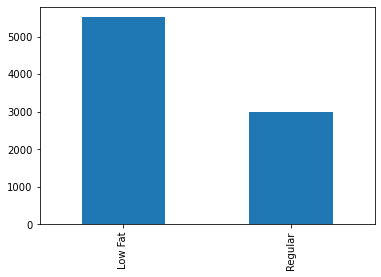

In [18]:
train_data['Item_Fat_Content'].value_counts().plot.bar()

Bi-Variate Analysis

<AxesSubplot:>

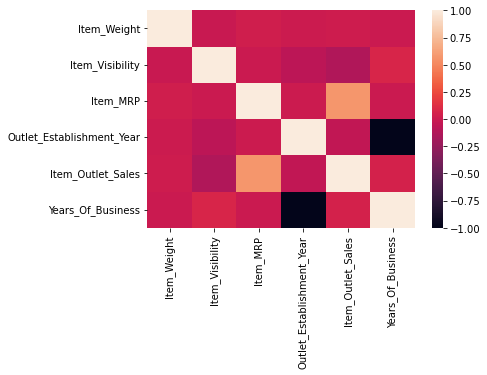

In [19]:
sns.heatmap(train_data.corr())

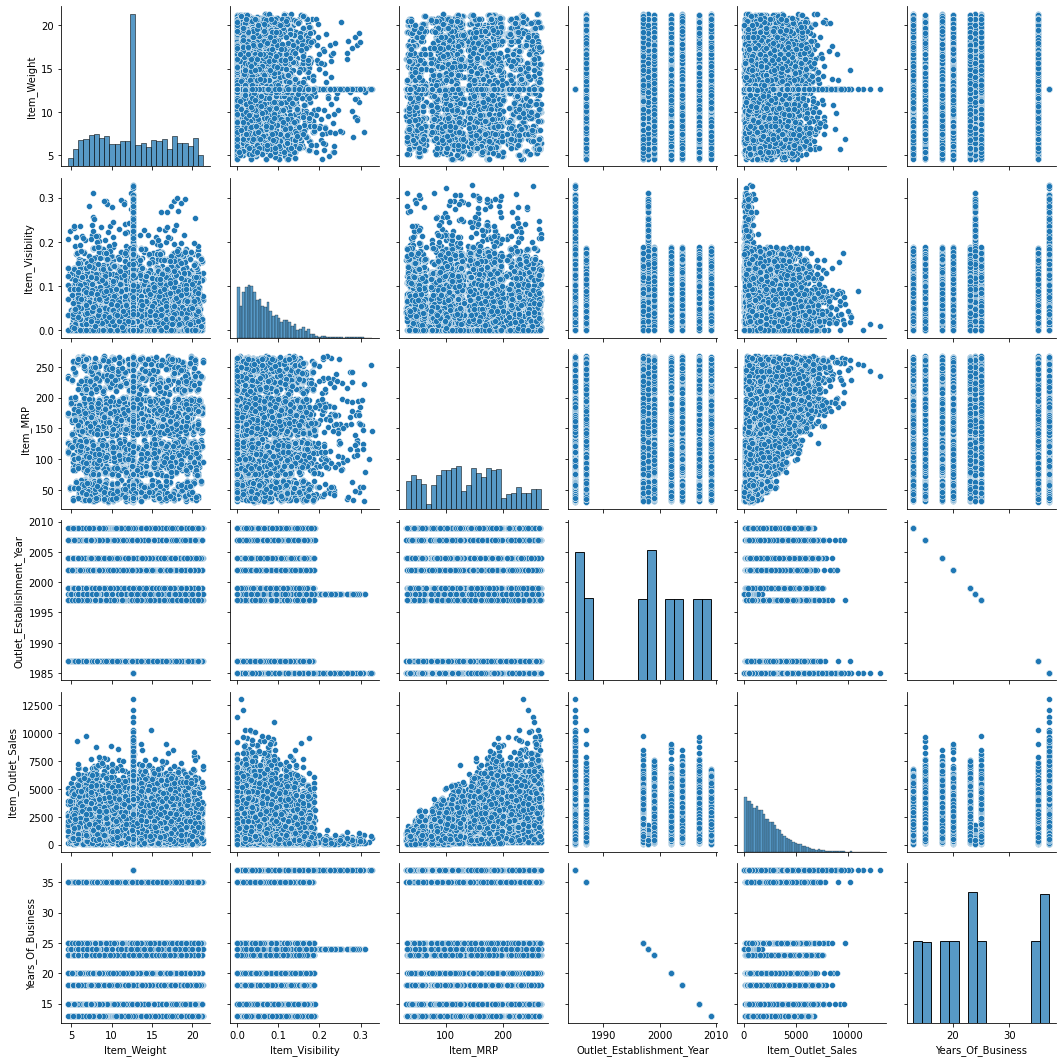

In [20]:
sns.pairplot(train_data)

Chi-square Test

In [21]:
from scipy.stats.contingency import chi2_contingency

In [22]:
def chi_sq(var1,var2): 
  crosstab = pd.crosstab(var1,var2)
  _,p,_,_ = chi2_contingency(crosstab)
  if p < 0.05:
    print(f"The relationship is strong , {round(p,2)}")
  else:
    print(f"The relationship is weak , {round(p,2)}") 
  return crosstab

In [23]:
train_data['Outlet_Size'].value_counts()

Medium    5203
Small     2388
High       932
Name: Outlet_Size, dtype: int64

In [24]:
train_data['Outlet_Location_Type'].value_counts()

Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: Outlet_Location_Type, dtype: int64

In [25]:
chi_sq(train_data['Outlet_Size'],train_data['Outlet_Location_Type'])

The relationship is strong , 0.0


Outlet_Location_Type,Tier 1,Tier 2,Tier 3
Outlet_Size,,,
High,0,0,932
Medium,930,1855,2418
Small,1458,930,0


In [26]:
chi_sq(train_data['Outlet_Location_Type'],train_data['Outlet_Size'])

The relationship is strong , 0.0


Outlet_Size,High,Medium,Small
Outlet_Location_Type,,,
Tier 1,0,930,1458
Tier 2,0,1855,930
Tier 3,932,2418,0


In [27]:
train_data['Outlet_Location_Type'].value_counts()

Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: Outlet_Location_Type, dtype: int64

In [28]:
train_data['Outlet_Type'].value_counts()

Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: Outlet_Type, dtype: int64

In [29]:
chi_sq(train_data['Outlet_Location_Type'],train_data['Outlet_Type'])

The relationship is strong , 0.0


Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Location_Type,,,,
Tier 1,528,1860,0,0
Tier 2,0,2785,0,0
Tier 3,555,932,928,935


Data Preparation for Modeling / Multi - Variate Analysis

Drop Variables

In [30]:
train_data.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales', 'Years_Of_Business'],
      dtype='object')

In [31]:
train_data.drop(['Item_Identifier','Outlet_Identifier','Outlet_Establishment_Year'],axis = 1, inplace  = True)

In [32]:
train_data.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Outlet_Sales', 'Years_Of_Business'],
      dtype='object')

In [33]:
x = train_data.drop(['Item_Outlet_Sales'],axis=1)

In [34]:
x.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Years_Of_Business
0,9.30,Low Fat,0.016047,Dairy,249.8092,Medium,Tier 1,Supermarket Type1,23
1,5.92,Regular,0.019278,Soft Drinks,48.2692,Medium,Tier 3,Supermarket Type2,13
2,17.50,Low Fat,0.016760,Meat,141.6180,Medium,Tier 1,Supermarket Type1,23
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,Medium,Tier 3,Grocery Store,24
4,8.93,Low Fat,0.000000,Household,53.8614,High,Tier 3,Supermarket Type1,35


In [35]:
y = train_data['Item_Outlet_Sales']

In [36]:
print(x.shape)
print(y.shape)

(8523, 9)
(8523,)


Encoding object variables variables

In [37]:
from sklearn.preprocessing import LabelEncoder


In [38]:
train_data.dtypes

Item_Weight             float64
Item_Fat_Content         object
Item_Visibility         float64
Item_Type                object
Item_MRP                float64
Outlet_Size              object
Outlet_Location_Type     object
Outlet_Type              object
Item_Outlet_Sales       float64
Years_Of_Business         int64
dtype: object

In [39]:
le = LabelEncoder()


In [40]:
for i in x.columns:
  if x[i].dtype == 'object':
    x[i] = le.fit_transform(x[i])
    

In [41]:
x.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Years_Of_Business
0,9.30,0,0.016047,4,249.8092,1,0,1,23
1,5.92,1,0.019278,14,48.2692,1,2,2,13
2,17.50,0,0.016760,10,141.6180,1,0,1,23
3,19.20,1,0.000000,6,182.0950,1,2,0,24
4,8.93,0,0.000000,9,53.8614,0,2,1,35


In [42]:
y.head()

0    3735.1380
1     443.4228
2    2097.2700
3     732.3800
4     994.7052
Name: Item_Outlet_Sales, dtype: float64

Train and Test split in data

In [43]:
x_train,x_test,y_train,y_test =  train_test_split(x, y, test_size=0.2, random_state=123)

In [44]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6818, 9)
(1705, 9)
(6818,)
(1705,)


Linear Regression 

In [45]:
lr = LinearRegression() 
lr.fit(x_train,y_train)
predict_train_lr = lr.predict(x_train)
predict_test_lr = lr.predict(x_test)

In [46]:
lr.intercept_

-246.79610396732005

In [47]:
lr.coef_

array([-1.13726234e-01,  5.84239364e+01, -1.40185422e+03, -2.84093096e+00,
        1.57264471e+01, -3.30133181e+02, -4.17412800e+02,  9.93463276e+02,
       -1.25046840e+00])

Model Evaluation

Train Accuracy

In [48]:
rmse_train = np.sqrt(mean_squared_error(y_train, predict_train_lr))
r_sq_train = r2_score(y_train, predict_train_lr)

Test Accuracy

In [49]:
rmse_test = np.sqrt(mean_squared_error(y_test, predict_test_lr))
r_sq_test = r2_score(y_test, predict_test_lr)

In [50]:
print (f"the rmse for the train data is : {round(rmse_train,2)}")
print (f"the rmse for the test data is : {round(rmse_test,2)}") 

print (f"the rsquare value for the train data is : {round(r_sq_train,2)}")
print (f"the rsquare value for the test data is : {round(r_sq_test,2)}") 


the rmse for the train data is : 1202.95
the rmse for the test data is : 1173.02
the rsquare value for the train data is : 0.51
the rsquare value for the test data is : 0.52


Application on Test data

In [52]:
data_prep(test_data)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Years_Of_Business
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,23
1,FDW14,8.300,Regular,0.038428,Dairy,87.3198,OUT017,2007,Medium,Tier 2,Supermarket Type1,15
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,Medium,Tier 3,Grocery Store,24
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Medium,Tier 2,Supermarket Type1,15
4,FDY38,12.500,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,37
...,...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1,25
5677,FDD47,7.600,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2,13
5678,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,Medium,Tier 2,Supermarket Type1,20
5679,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,2007,Medium,Tier 2,Supermarket Type1,15


In [53]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                5681 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                5681 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
 11  Years_Of_Business          5681 non-null   int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 532.7+ KB


In [54]:
test_data['Item_Fat_Content'].value_counts()

Low Fat    3668
Regular    2013
Name: Item_Fat_Content, dtype: int64

In [55]:
test_data.drop(['Item_Identifier','Outlet_Identifier','Outlet_Establishment_Year'],axis = 1, inplace  = True)

In [56]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item_Weight           5681 non-null   float64
 1   Item_Fat_Content      5681 non-null   object 
 2   Item_Visibility       5681 non-null   float64
 3   Item_Type             5681 non-null   object 
 4   Item_MRP              5681 non-null   float64
 5   Outlet_Size           5681 non-null   object 
 6   Outlet_Location_Type  5681 non-null   object 
 7   Outlet_Type           5681 non-null   object 
 8   Years_Of_Business     5681 non-null   int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 399.6+ KB


In [57]:
for i in test_data.columns:
  if test_data[i].dtype == 'object':
    test_data[i] = le.fit_transform(test_data[i])
    

In [58]:
test_data.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Years_Of_Business
0,20.750,0,0.007565,13,107.8622,1,0,1,23
1,8.300,1,0.038428,4,87.3198,1,1,1,15
2,14.600,0,0.099575,11,241.7538,1,2,0,24
3,7.315,0,0.015388,13,155.0340,1,1,1,15
4,12.500,1,0.118599,4,234.2300,1,2,3,37


In [59]:
Item_outlet_sales_test = lr.predict(test_data)

In [60]:
Item_outlet_sales_test

array([2034.16568005, 1345.84066338, 2187.66206892, ..., 1714.59202286,
       3403.76367894, 1131.03775394])

In [61]:
 submission = pd.read_csv("sample_submission.csv")

In [62]:
submission.head()

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1000
1,FDW14,OUT017,1000
2,NCN55,OUT010,1000
3,FDQ58,OUT017,1000
4,FDY38,OUT027,1000


In [63]:
type(Item_outlet_sales_test)

numpy.ndarray

In [64]:
submission['Item_Outlet_Sales'] = Item_outlet_sales_test

In [65]:
submission.head()

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,2034.165680
1,FDW14,OUT017,1345.840663
2,NCN55,OUT010,2187.662069
3,FDQ58,OUT017,2359.161870
4,FDY38,OUT027,5085.353001


In [66]:
submission.to_csv('final_submission.csv',index=False)